# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [2]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [3]:
e_1 = A @ np.array([1,0,0]) 
e_2 = A @ np.array([0,1,0])
e_3 = A @ np.array([0,0,1])

print(e_1)
print(e_2) 
print(e_3) 

[1 4 7]
[2 5 8]
[3 6 9]


When you a multiple a matrix times a vector, the result is a new vector that is created by taking the dot product of each row of A (the matrix) with e (the vector). For example, e_1 is obtained by taking the dot produce of each row of A with the vector [1, 0, 0]. The first row of A is multiplied by [1, 0, 0] to obtain the first element of e_1. Same with the second row of A and the third row of A. 

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [4]:
u = np.ones(3) 
print(u) 

[1. 1. 1.]


In [5]:
u = A @ u
print(u)

[ 6. 15. 24.]


This output is correct because of the definition of matrix multiplication. For this example, the vector [1, 1, 1] is multiplied to each row of A to obtain the elements of the output. The first element of the vector was taken by taking the  dot product of the first row of A with u. Which would be [(1 * 1) + (2 * 1) + (3 * 1)] for the first element, [(4 * 1) + (5 * 1) + (6 * 1)] for the second element, and [(7 * 1) + (8 * 1) + (9 * 1)] for the third element.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [6]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])

output = A @ x
print(output) 


[-2  4 11]


Multiplication with an identity matrix leaves the matrix unchanged. This is because when you conduct matrix multiplication, you are multiplying each element by 1 to keep it the same number, and then adding 0s to it, which leaves that first element unchanged.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [7]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])

output_d = A @ x
print(output_d) 


[11 -2  4]


In [8]:
A = np.array([ [0,1,0],
              [1,0,0],
              [0,0,1]])
x = np.array([-2,4,11])

output_d2 = A @ x
print(output_d2)

[ 4 -2 11]


Having a matrix with rows and columns that sum to 1 that are not an identity matrix keeps all the elements the same, but changes the order of them in the output. For example, in the doubly stochastic matrix I created in output_d2, the element order is changed to be in the same order as where the 1 appears in the matrix. So, the second element 4 will appear first because the 1 in the first row of A is in the same place as the 4 in the vector. Same with -2, the second row has 1 in the first element of the vector so the output vector will have -2 be the second element of the output. 

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [9]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)


[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [10]:
e_1 = np.array([1, 0, 0])
e_2 = np.array([0, 1, 0])
e_3 = np.array([0, 0, 1])

result_1 = A @ e_1
result_2 = A @ e_2
result_3 = A @ e_3

print(result_1)
print(result_2)
print(result_3)

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


This problem is similar to question 1 where we are multiplying this random matrix A by 3 vectors that create an identity matrix when joined together. As a result, the matrix is now split by column instead of row, so the result of A multiplied by e_1 is the first column of matrix A. 

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [11]:
for e in [e_1, e_2, e_3]:
    v = e.copy()
    for i in range(5):
        v = A @ v
    print(v)

[0.29266551 0.27862515 0.42870935]
[0.29197422 0.27979983 0.42822595]
[0.29171646 0.2802254  0.42805814]


For each starting vector, we get very similar values for each element of each output vector. The element values converge to a simliar value despite whatever ei we start with.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\

.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [12]:
import numpy as np 
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [13]:
T

array([[0.25, 0.5 ],
       [0.75, 0.5 ]])

In [14]:
init_condition = np.array([1,0])
print(init_condition)

[1 0]


In [15]:
p_1 = T @ init_condition
print(p_1)

[0.25 0.75]


This object we are looking at is the first column of matrix T. 

In [16]:
p_2 = T @ p_1 
print(p_2)

[0.4375 0.5625]


When we multiply by T again, the vector after two steps is not simply a single column but a combination of the columns of T multiplied by the given weights. This means when we multiply by T we get 0.25 * the first column of T + 0.75 * the second column of T. This means it is forecasting the distribution in period two, not a column. 

In [17]:
n = 100 
p = np.array([1,0])
for t in range(n): 
    print(p ) 
    p = T @ p


[1 0]
[0.25 0.75]
[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]
[0.40000004 0.59999996]
[0.39999999 0.60000001]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0.6]
[0.4 0

The first few interations are different but it eventually converges to 0.4, 0.6 around the 15th iteration. 

In [18]:
n = 100000
state = 0 
sim = [] 
for t in range(n): 
    sim.append(state)
    prob = T[:, state]
    state = np.random.choice(a = [0,1], p = prob)

sim

[0,
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 n

The long-run distribution does NOT depend on whether you started in state 1 or state 2.

In [19]:
x = np.array(sim) 
np.mean(x) 


np.float64(0.59997)

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [20]:
import pandas as pd
weather = pd.read_csv('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/cville_weather.csv')
weather

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [21]:
weather.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

Yes, there are a lot of missing values in this data set. 

In [22]:
weather["rain"] = (weather["PRCP"]> 0).astype(int) 
weather[["DATE", "rain", "PRCP"]].head()

,DATE,rain,PRCP
0,2024-01-04,1,0.03
1,2024-01-07,1,1.08
2,2024-01-09,1,0.24
3,2024-01-10,1,3.00
4,2024-01-24,0,0.00


In [23]:

weather["rain_yesterday"] = weather["rain"].shift(1)
transitions = weather.dropna(subset=["rain_yesterday"])

counts = pd.crosstab(transitions["rain"], transitions["rain_yesterday"])
print(counts)

T = counts / counts.sum(axis=0)
print("Transition matrix:\n", T)


rain_yesterday  0.0  1.0
rain                    
0               169   63
1                62  116
Transition matrix:
 rain_yesterday       0.0       1.0
rain                              
0               0.731602  0.351955
1               0.268398  0.648045


From these transition probabilities, we can see that it means: 
- if it rains today, there is 64.8% chance that it rains tomorrow. 
- if it's clear today, there's only a 26.8% chance that it rains tomorrow.

In [24]:
v_clear = np.array([1, 0])   # 100% chance clear
v_rainy = np.array([0, 1])   # 100% chance rainy

def iterate_forecast(T, v, steps=10):
    hist = [v]
    for _ in range(steps):
        v = T @ v
        hist.append(v)
    return np.array(hist)

forecast_clear = iterate_forecast(T.values, v_clear)
forecast_rainy = iterate_forecast(T.values, v_rainy)

print("Starting clear:")
print(forecast_clear[:6])

print("Starting rainy:")
print(forecast_rainy[:6])


Starting clear:
[[1.         0.        ]
 [0.73160173 0.26839827]
 [0.62970529 0.37029471]
 [0.59102067 0.40897933]
 [0.57633419 0.42366581]
 [0.57075852 0.42924148]]
Starting rainy:
[[0.         1.        ]
 [0.35195531 0.64804469]
 [0.48557388 0.51442612]
 [0.5363017  0.4636983 ]
 [0.55556033 0.44443967]
 [0.5628718  0.4371282 ]]


From these values, we can see that if we keep iterating through, it will eventually converge at a certain value. For us, it is a 50-50% chance whether we start on a clear day or a rainy day. The distribution begins to settle around the third to fourth iteration.

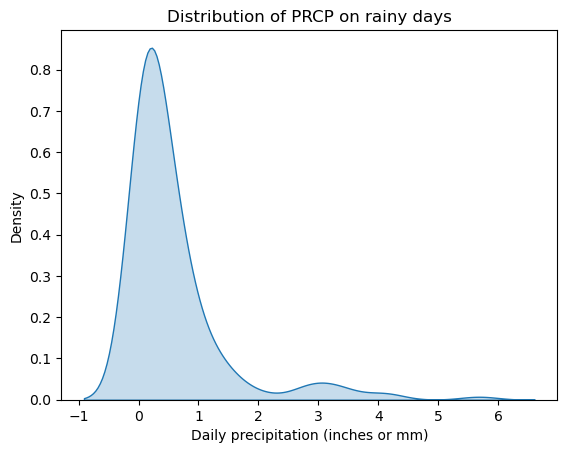

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=weather[weather["rain"] == 1], x="PRCP", fill=True)
plt.title("Distribution of PRCP on rainy days")
plt.xlabel("Daily precipitation (inches or mm)")
plt.show()


From this KDE plot, we can see that this plot is right-skewed. This means that there are more days with a light precipitation and fewer days with a heavier precipitation.

To improve our model, we can include more factors that may influence weather such as temperature or humidity as covariates. We can also make it vary by season or time of year. 

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [ ]:
import pandas as pd 
import re
from collections import defaultdict 

#taxi = pd.read_pickle('/Users/bellalu/DS 5030/DS5030UnderstandingUncertainty/taxicab.pkl')

def parse_row(row_text):
    # Updated pattern to include apostrophes
    pattern = r'(\d+)\s+([A-Za-z\s\']+?)(?=\s+\d+|$)'
    matches = re.findall(pattern, row_text)
    
    area_counts = defaultdict(int)
    for count, area in matches:
        area_counts[area.strip()] += int(count)
    
    return dict(area_counts)

parsed_data = [parse_row(str(row)) for row in taxi]

df = pd.DataFrame(parsed_data).fillna(0)
df

,Outside Manhattan,SoHo,Greenwich Village,Chelsea,Midtown,Kips Bay,East Village,Upper East Side,Lower East Side,East Harlem,...,Theater District,Washington Heights,Civic Center,Chinatown,Little Italy,NoHo,Inwood,Marble Hill,Two Bridges,Roosevelt Island
0,0.0,58.0,13.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,22.0,34.0,7.0,136.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,3.0,0.0,0.0,0.0,136.0,40.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,13.0,6.0,22.0,0.0,7.0,0.0,20.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,29.0,0.0,3.0,0.0,0.0,21.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,44.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,17.0,7.0,102.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,3.0,22.0,0.0,0.0,34.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


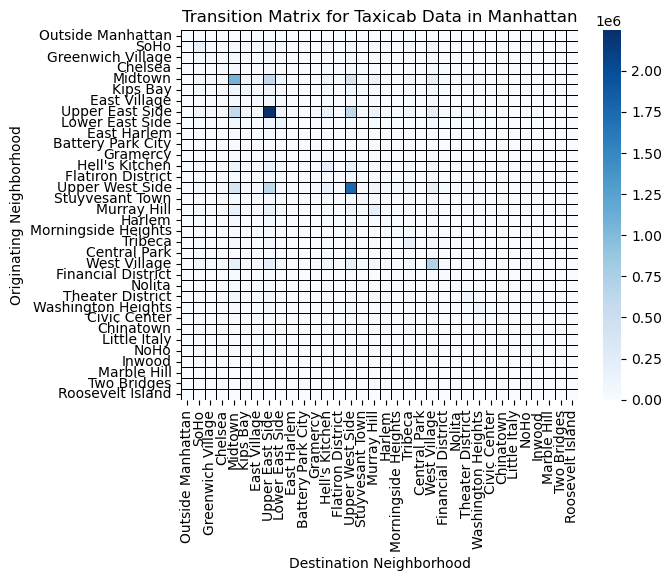

In [27]:
#transition matrix 

transition_matrix = df.T.dot(df) 

#heat map 
sns.heatmap(transition_matrix, annot=False, cmap='Blues', linewidths=0.5, xticklabels=1, yticklabels=1, linecolor='black')
plt.title('Transition Matrix for Taxicab Data in Manhattan')
plt.xlabel('Destination Neighborhood')
plt.ylabel('Originating Neighborhood')
plt.show()

Looking at this graph, the most common routes (denoted by how dark the squares are) are Upper East Side and Upper West side. Upper East Side with Midtown is also pretty common. 

It makes sense to order one taxi rather than 2 or more becuase most people are taking individual trips based on the data provided. Because they are individual rides, most individuals are hailing a cab to be taken to a very specific destination that varies from passenger to passenger. Another reason could be limit of passengers one taxi can have. 

In [28]:
current = "Hell's Kitchen"

# Track the path
path = [current]

# Simulate 10 trips
for i in range(10):
    # Find the most likely next location (excluding current location)
    possible_next = transition_matrix.loc[current].drop(current)
    next_location = possible_next.idxmax()
    path.append(next_location)
    current = next_location
    
    # Print at specific steps
    if i + 1 in [2, 3, 5, 10]:
        print(f"After {i+1} trips: {next_location}")

print(f"\nFull path: {' → '.join(path)}")


After 2 trips: Upper East Side
After 3 trips: Upper West Side
After 5 trips: Upper West Side
After 10 trips: Upper East Side

Full path: Hell's Kitchen → Upper West Side → Upper East Side → Upper West Side → Upper East Side → Upper West Side → Upper East Side → Upper West Side → Upper East Side → Upper West Side → Upper East Side


In [36]:
transition_matrix.sum(axis=1)
transition_matrix = transition_matrix.fillna(0)

row_sums = transition_matrix.sum(axis=1)
zero_rows = row_sums[row_sums == 0].index

for row in zero_rows:
    transition_matrix.loc[row] = 1 / len(transition_matrix)

# renormalize all the rows 
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)


In [37]:
# Initialize starting distribution (e.g., uniform across all neighborhoods)
pi = np.ones(len(transition_matrix)) / len(transition_matrix)
pi = pd.Series(pi, index=transition_matrix.index)

# Iterate until convergence
tolerance = 1e-8
delta = 1.0

while delta > tolerance:
    new_pi = pi.dot(transition_matrix)
    delta = np.linalg.norm(new_pi - pi)
    pi = new_pi

# Normalize just in case of rounding errors
pi = pi / pi.sum()

# Sort and display
steady_state = pi.sort_values(ascending=False)
print("Steady-state distribution (most likely cab locations):")
print(steady_state.head(10))



Steady-state distribution (most likely cab locations):
Upper East Side    0.227223
Upper West Side    0.179767
Midtown            0.150605
West Village       0.088173
Hell's Kitchen     0.044564
Murray Hill        0.040179
SoHo               0.029150
Tribeca            0.028559
Lower East Side    0.027625
Kips Bay           0.025134
dtype: float64


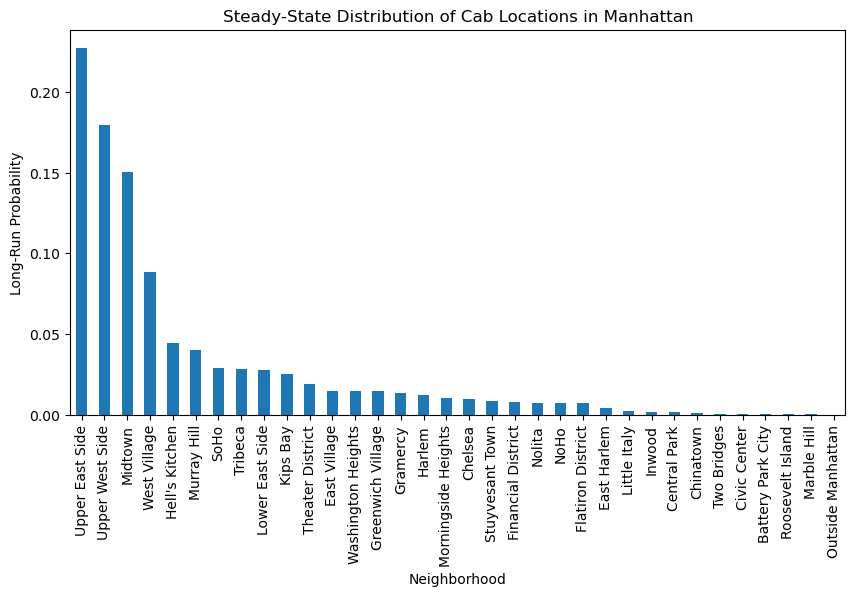

In [38]:
import matplotlib.pyplot as plt

steady_state.plot(kind='bar', figsize=(10, 5))
plt.title("Steady-State Distribution of Cab Locations in Manhattan")
plt.ylabel("Long-Run Probability")
plt.xlabel("Neighborhood")
plt.show()


Most of the cabs spend their time working on the Upper East Side, Upper West Side, and Midtown.